# Direct Preference Optimization (DPO) Analysis

$$\mathcal{L}_{\text{DPO}}(\pi_\theta; \pi_{\text{ref}}) = -\mathbb{E}_{(x, a^{+}, a^{-}) \sim \mathcal{D}} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(a^{+} \mid x)}{\pi_{\text{ref}}(a^{+} \mid x)} - \beta \log \frac{\pi_\theta(a^{-} \mid x)}{\pi_{\text{ref}}(a^{-} \mid x)} \right) \right]$$

We need:
1. A **policy model** $\pi_\theta$
2. A frozen **reference model** $\pi_{\text{ref}}$
3. The **DPO loss function**
4. A **training loop** that handles both models

### Import the Necessary Packages

In [2]:
import gym
import numpy as np
from collections import deque
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

This environment is part of the Classic Control environments which contains general information about the environment.

| Property | Value |
|---|---|
| Action Space | `Discrete(2)` |
| Observation Space | `Box([-4.8 -inf -0.41887903 -inf], [4.8 inf 0.41887903 inf], (4,), float32)` |
| Create environment | `gymnasium.make("Pendulum-v1")` |

In [4]:
env = gym.make('Pendulum-v1')
env.seed(0)

/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


[0]

### Policy Network Architecture

Defined by a two-layer feedforward going from state_size to hidden_size and then to action_size. The activation function used is ReLU.

In [5]:
class Policy(nn.Module):
    def __init__(self, env, hidden_size=64):
        super(Policy, self).__init__()

        obs_shape = env.observation_space.shape
        self.state_size = int(obs_shape[0])
        self.is_discrete = isinstance(env.action_space, gym.spaces.Discrete)

        self.fc1 = nn.Linear(self.state_size, hidden_size)

        if self.is_discrete:
            self.action_size = int(env.action_space.n)
            self.fc_out = nn.Linear(hidden_size, self.action_size)
        else:
            self.action_size = int(env.action_space.shape[0])
            self.fc_mean = nn.Linear(hidden_size, self.action_size)
            self.log_std = nn.Parameter(torch.zeros(self.action_size))
            self.action_low = torch.as_tensor(env.action_space.low, dtype=torch.float32, device=device)
            self.action_high = torch.as_tensor(env.action_space.high, dtype=torch.float32, device=device)

    def _features(self, state):
        return F.relu(self.fc1(state))

    def _distribution(self, state):
        x = self._features(state)
        if self.is_discrete:
            logits = self.fc_out(x)
            probs = F.softmax(logits, dim=-1)
            return Categorical(probs)

        mean = self.fc_mean(x)
        std = torch.exp(self.log_std).expand_as(mean)
        return torch.distributions.Normal(mean, std)

    def forward(self, state):
        # Keep forward as "action probabilities" for discrete to preserve notebook usage.
        dist = self._distribution(state)
        if self.is_discrete:
            return dist.probs
        return dist.mean

    def log_prob_actions(self, states, actions):
        dist = self._distribution(states)
        if self.is_discrete:
            return dist.log_prob(actions.long())

        if actions.ndim == 1:
            actions = actions.unsqueeze(-1)
        return dist.log_prob(actions).sum(dim=-1)

    def act(self, state, deterministic=False):
        state_np = np.asarray(state, dtype=np.float32)
        state_t = torch.from_numpy(state_np).float().unsqueeze(0).to(device)
        dist = self._distribution(state_t)

        if self.is_discrete:
            if deterministic:
                action = torch.argmax(dist.probs, dim=-1)
            else:
                action = dist.sample()
            log_prob = dist.log_prob(action)
            return int(action.item()), log_prob.squeeze(0)

        if deterministic:
            action = dist.mean
        else:
            action = dist.sample()
        clipped_action = torch.max(torch.min(action, self.action_high), self.action_low)
        log_prob = dist.log_prob(action).sum(dim=-1)
        return clipped_action.squeeze(0).detach().cpu().numpy(), log_prob.squeeze(0)

### The DPO Loss Function

$$\mathcal{L}_{\text{DPO}} = -\log \sigma\left( \beta \cdot \left[ \left(\log \pi_\theta(a^{+}|x) - \log \pi_{\text{ref}}(a^{+}|x)\right) - \left(\log \pi_\theta(a^{-}|x) - \log \pi_{\text{ref}}(a^{-}|x)\right) \right] \right)$$

In [6]:
def dpo_loss(
    policy_chosen_logps: torch.FloatTensor,
    policy_rejected_logps: torch.FloatTensor,
    reference_chosen_logps: torch.FloatTensor,
    reference_rejected_logps: torch.FloatTensor,
    beta: float,
) -> Tuple[torch.FloatTensor, torch.FloatTensor, torch.FloatTensor]:
    """Compute the DPO loss for a batch of policy and reference model log probabilities.

    Args:
        policy_chosen_logps: Log probabilities of the policy model for chosen responses.
                             Shape: (batch_size,)
        policy_rejected_logps: Log probabilities of the policy model for rejected responses.
                               Shape: (batch_size,)
        reference_chosen_logps: Log probabilities of the reference model for chosen responses.
                                Shape: (batch_size,)
        reference_rejected_logps: Log probabilities of the reference model for rejected responses.
                                  Shape: (batch_size,)
        beta: Temperature parameter for DPO.

    Returns:
        losses: DPO loss for each example. Shape: (batch_size,)
        chosen_rewards: Implicit reward for chosen responses. Shape: (batch_size,)
        rejected_rewards: Implicit reward for rejected responses. Shape: (batch_size,)
    """
    # Step 1: Compute log-ratio of chosen vs rejected under the policy
    pi_logratios = policy_chosen_logps - policy_rejected_logps

    # Step 2: Compute log-ratio of chosen vs rejected under the reference
    ref_logratios = reference_chosen_logps - reference_rejected_logps

    # Step 3: The "logits" for the DPO loss
    logits = pi_logratios - ref_logratios

    # Step 4: DPO loss = -log sigmoid(beta * logits)
    losses = -F.logsigmoid(beta * logits)

    # Step 5: Compute implicit rewards for monitoring
    # r_hat(x, y) = beta * (log pi_theta(y|x) - log pi_ref(y|x))
    chosen_rewards = beta * (policy_chosen_logps - reference_chosen_logps).detach()
    rejected_rewards = beta * (policy_rejected_logps - reference_rejected_logps).detach()

    return losses, chosen_rewards, rejected_rewards


### Concatenated Forward Pass + DPO Batch Metrics

For efficiency, we concatenate the chosen and rejected inputs into a single batch and do one forward pass. This avoids running the model twice per example.

In [7]:
from pathlib import Path
import json

PREF_DIR = Path('data_generation/outputs/preferences')
PREF_PATH = PREF_DIR / 'Pendulum-v1_K1000_s5.json'

def load_preference_dataset(path: Path):
    """Load an offline preference dataset from JSON."""
    with path.open() as f:
        data = json.load(f)
    return data


def trajectory_logp(policy: Policy, trajectory: Dict) -> torch.Tensor:
    """Sum log-probabilities of the actions taken in one trajectory."""
    states = torch.as_tensor(trajectory['states'], dtype=torch.float32, device=device)
    if policy.is_discrete:
        actions = torch.as_tensor(trajectory['actions'], dtype=torch.long, device=device)
    else:
        actions = torch.as_tensor(trajectory['actions'], dtype=torch.float32, device=device)

    per_step_logp = policy.log_prob_actions(states, actions)
    return per_step_logp.sum()


def preference_pair_logps(policy: Policy, pair: Dict):
    """Return policy log-probabilities for the preferred and rejected trajectories."""
    if pair['preferred'] == 0:
        chosen = pair['tau1']
        rejected = pair['tau2']
    else:
        chosen = pair['tau2']
        rejected = pair['tau1']

    chosen_logp = trajectory_logp(policy, chosen)
    rejected_logp = trajectory_logp(policy, rejected)
    return chosen_logp, rejected_logp

In [8]:
def train_dpo(
    policy_model: nn.Module,
    reference_model: nn.Module,
    optimizer: optim.Optimizer,
    preference_data: Dict,
    n_epochs: int = 20,
    print_every: int = 1,
    early_stop: bool = False,
    target_score: float = 195.0,
 ):
    """Simple offline DPO training loop over a preference dataset."""
    scores = []
    pairs = preference_data['pairs']

    reference_model.eval()

    for epoch in range(1, n_epochs + 1):
        epoch_losses = []

        for pair in pairs:
            policy_chosen_logp, policy_rejected_logp = preference_pair_logps(policy_model, pair)
            with torch.no_grad():
                reference_chosen_logp, reference_rejected_logp = preference_pair_logps(reference_model, pair)

            loss, chosen_rewards, rejected_rewards = dpo_loss(
                policy_chosen_logps=policy_chosen_logp,
                policy_rejected_logps=policy_rejected_logp,
                reference_chosen_logps=reference_chosen_logp,
                reference_rejected_logps=reference_rejected_logp,
                beta=0.1,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        mean_loss = float(np.mean(epoch_losses))
        scores.append(mean_loss)

        if epoch % print_every == 0:
            print(f"Epoch {epoch}\tAverage Loss: {mean_loss:.4f}")

        if early_stop and mean_loss < 0.3:
            print(f"Stopped early at epoch {epoch}\tAverage Loss: {mean_loss:.4f}")
            break

    return scores

In [9]:
preference_data = load_preference_dataset(PREF_PATH)

policy_model = Policy(env).to(device)
reference_model = Policy(env).to(device)
reference_model.load_state_dict(policy_model.state_dict())
reference_model.eval()

optimizer = optim.Adam(policy_model.parameters(), lr=1e-3)

print(f"Loaded {PREF_PATH.name} with {len(preference_data['pairs'])} preference pairs")
print(f"Policy mode: {'discrete' if policy_model.is_discrete else 'continuous'}")

FileNotFoundError: [Errno 2] No such file or directory: 'data_generation/outputs/preferences/Pendulum-v1_K1000_s5.json'

In [ ]:
scores = train_dpo(
    policy_model=policy_model,
    reference_model=reference_model,
    optimizer=optimizer,
    preference_data=preference_data,
    n_epochs=1,
    print_every=1,
    early_stop=False,
 )
print(f"Final average loss: {np.mean(scores[-5:]):.4f}")

Epoch 1	Average Loss: 0.0389
Epoch 2	Average Loss: 0.0376
Epoch 3	Average Loss: 0.0368
Epoch 4	Average Loss: 0.0363
Epoch 5	Average Loss: 0.0362
Epoch 6	Average Loss: 0.0360
Epoch 7	Average Loss: 0.0354
Epoch 8	Average Loss: 0.0346
Epoch 9	Average Loss: 0.0338
Epoch 10	Average Loss: 0.0329
Epoch 11	Average Loss: 0.0320
Epoch 12	Average Loss: 0.0310
Epoch 13	Average Loss: 0.0300
Epoch 14	Average Loss: 0.0290
Epoch 15	Average Loss: 0.0282
Epoch 16	Average Loss: 0.0274
Epoch 17	Average Loss: 0.0266
Epoch 18	Average Loss: 0.0258
Epoch 19	Average Loss: 0.0251
Epoch 20	Average Loss: 0.0244
Final average loss: 0.0258


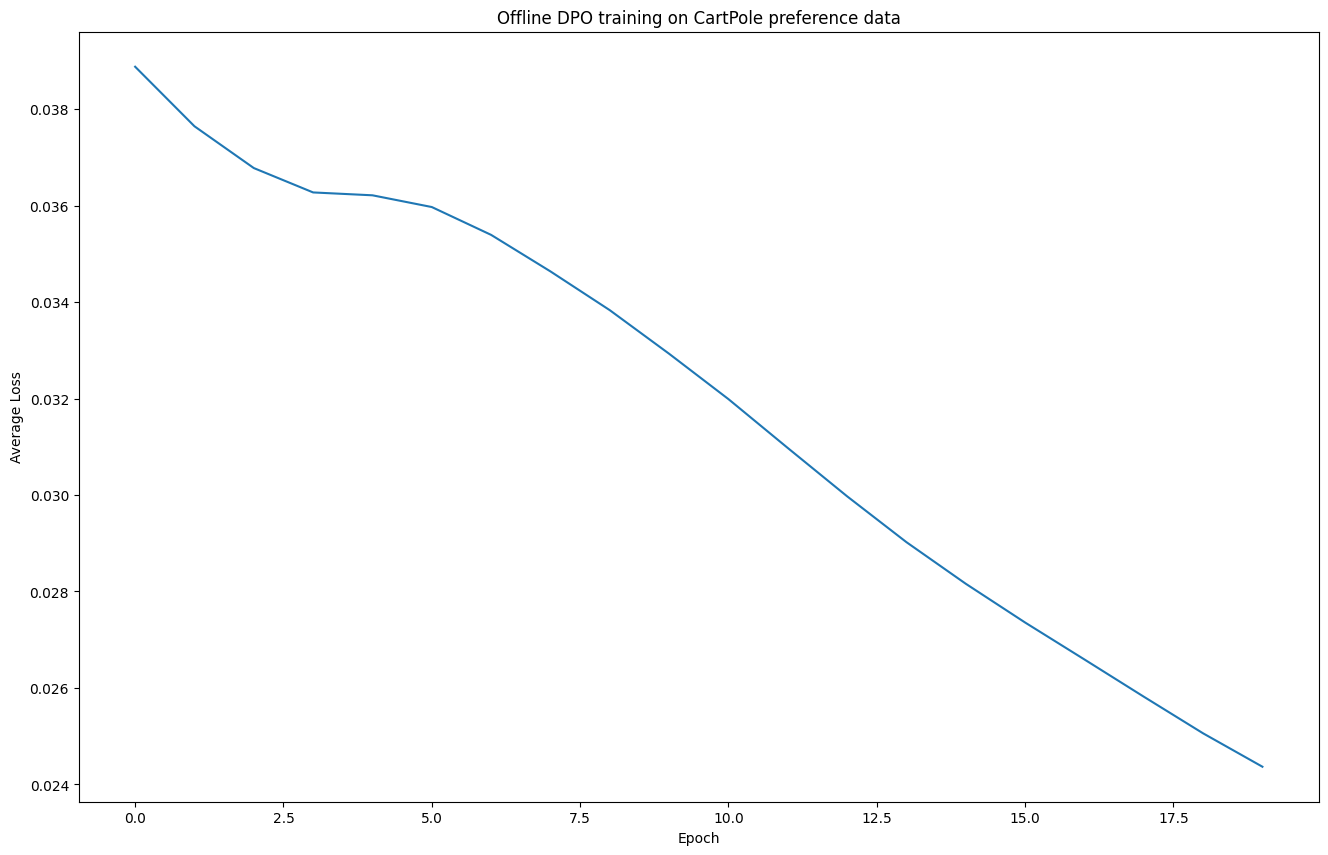

In [ ]:
plt.plot(scores)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Offline DPO training on CartPole preference data")
plt.show()

In [ ]:
from utils import show_video_of_model
save_path = './demos/'
# create video
policy = policy_model
show_video_of_model(save_path, policy, 'Pendulum-v1')
# show video
show_video('Pendulum-v1')

NameError: name 'policy_model' is not defined

In [ ]:
def evaluate_policy_returns(policy: Policy, env_name: str = 'Pendulum-v1', n_episodes: int = 50, max_t: int = 500, deterministic: bool = True):
    """Run evaluation episodes and return mean/std episode return."""
    eval_env = gym.make(env_name)
    returns = []

    for _ in range(n_episodes):
        reset_out = eval_env.reset()
        state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
        episode_return = 0.0

        for _ in range(max_t):
            action, _ = policy.act(state, deterministic=deterministic)
            step_out = eval_env.step(action)
            if len(step_out) == 5:
                next_state, reward, terminated, truncated, _ = step_out
                done = terminated or truncated
            else:
                next_state, reward, done, _ = step_out

            episode_return += reward
            state = next_state
            if done:
                break

        returns.append(episode_return)

    eval_env.close()
    mean_return = float(np.mean(returns))
    std_return = float(np.std(returns))

    print(f"Evaluation over {n_episodes} episodes")
    print(f"Mean episode return: {mean_return:.2f}")
    print(f"Std episode return:  {std_return:.2f}")

    return returns, mean_return, std_return


eval_returns, eval_mean, eval_std = evaluate_policy_returns(
    policy_model, env_name='Pendulum-v1', n_episodes=50, max_t=200, deterministic=True
)

/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


Evaluation over 50 episodes
Mean episode return: -1484.59
Std episode return:  49.60
